In [1]:
# STEP 12: Analyze churn across major customer segments

import pandas as pd
import numpy as np
from pathlib import Path

# ---------------------------------------------------
# 1. Load engineered customer dataset
# ---------------------------------------------------

data_path = Path("../../data/cleaned")

customers = pd.read_csv(
    data_path / "customer_features.csv"
)

# ---------------------------------------------------
# 2. Helper function for churn summary
# ---------------------------------------------------

def churn_summary(df, group_col):
    
    result = (
        df.groupby(group_col)
        .agg(
            customers=("customer_id", "nunique"),
            churned_customers=("churn_flag", "sum")
        )
        .reset_index()
    )
    
    result["churn_rate_pct"] = (
        result["churned_customers"]
        / result["customers"]
        * 100
    ).round(2)
    
    return result.sort_values(
        "churn_rate_pct",
        ascending=False
    )


# ---------------------------------------------------
# 3. Churn by plan type
# ---------------------------------------------------

churn_by_plan_type = churn_summary(
    customers,
    "plan_type"
)

print("CHURN BY PLAN TYPE")
display(churn_by_plan_type)


# ---------------------------------------------------
# 4. Churn by plan tier
# ---------------------------------------------------

churn_by_plan_tier = churn_summary(
    customers,
    "plan_tier"
)

print("CHURN BY PLAN TIER")
display(churn_by_plan_tier)


# ---------------------------------------------------
# 5. Churn by acquisition channel
# ---------------------------------------------------

churn_by_channel = churn_summary(
    customers,
    "acquisition_channel"
)

print("CHURN BY ACQUISITION CHANNEL")
display(churn_by_channel)


# ---------------------------------------------------
# 6. Churn by primary device
# ---------------------------------------------------

churn_by_device = churn_summary(
    customers,
    "primary_device"
)

print("CHURN BY PRIMARY DEVICE")
display(churn_by_device)


# ---------------------------------------------------
# 7. Churn by age group
# ---------------------------------------------------

churn_by_age = churn_summary(
    customers,
    "age_group"
)

print("CHURN BY AGE GROUP")
display(churn_by_age)

CHURN BY PLAN TYPE


,plan_type,customers,churned_customers,churn_rate_pct
1,monthly,2661,1362,51.18
0,annual,1539,406,26.38


CHURN BY PLAN TIER


,plan_tier,customers,churned_customers,churn_rate_pct
2,premium,723,314,43.43
0,basic,1976,831,42.05
1,plus,1501,623,41.51


CHURN BY ACQUISITION CHANNEL


,acquisition_channel,customers,churned_customers,churn_rate_pct
3,promo_offer,949,482,50.79
2,partner,476,204,42.86
0,organic,1298,532,40.99
1,paid_social,989,385,38.93
4,referral,488,165,33.81


CHURN BY PRIMARY DEVICE


,primary_device,customers,churned_customers,churn_rate_pct
0,android,1550,697,44.97
1,ios,1976,799,40.44
2,web,674,272,40.36


CHURN BY AGE GROUP


,age_group,customers,churned_customers,churn_rate_pct
0,18-24,717,307,42.82
3,45-54,619,264,42.65
1,25-34,1400,594,42.43
2,35-44,1073,451,42.03
4,55+,391,152,38.87


CHURN BY TENURE BAND


,tenure_band,customers,churned_customers,churn_rate_pct
0,0-1 months,279,279,100.00
1,13-18 months,533,48,9.01
2,2-3 months,752,490,65.16
3,4-6 months,1030,361,35.05
4,7-12 months,1606,590,36.74


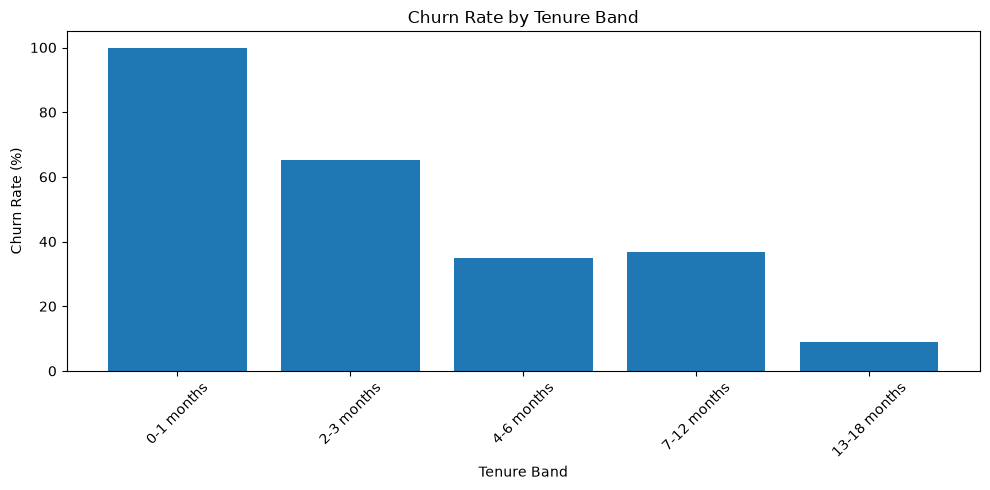

In [2]:
# STEP 13: Analyze churn by tenure band

# ---------------------------------------------------
# 1. Churn summary by tenure band
# ---------------------------------------------------

churn_by_tenure = (
    customers.groupby("tenure_band", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum")
    )
    .reset_index()
)

# ---------------------------------------------------
# 2. Calculate churn rate
# ---------------------------------------------------

churn_by_tenure["churn_rate_pct"] = (
    churn_by_tenure["churned_customers"]
    / churn_by_tenure["customers"]
    * 100
).round(2)

# ---------------------------------------------------
# 3. Display result
# ---------------------------------------------------

print("CHURN BY TENURE BAND")
display(churn_by_tenure)

# ---------------------------------------------------
# 4. Sort by tenure order
# ---------------------------------------------------

tenure_order = [
    "0-1 months",
    "2-3 months",
    "4-6 months",
    "7-12 months",
    "13-18 months",
    "18+ months"
]

churn_by_tenure["tenure_band"] = pd.Categorical(
    churn_by_tenure["tenure_band"],
    categories=tenure_order,
    ordered=True
)

churn_by_tenure = churn_by_tenure.sort_values("tenure_band")

# ---------------------------------------------------
# 5. Plot churn by tenure
# ---------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    churn_by_tenure["tenure_band"].astype(str),
    churn_by_tenure["churn_rate_pct"]
)

plt.title("Churn Rate by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

CHURN BY FIRST-MONTH ENGAGEMENT


,first_month_engagement_band,customers,churned_customers,avg_first_month_workouts,avg_first_month_minutes,churn_rate_pct
3,Very Low,1067,596,0.637301,18.962512,55.86
1,Low,1262,594,2.446910,73.324089,47.07
2,Medium,1283,450,5.137958,150.890881,35.07
0,High,588,128,10.819728,328.245748,21.77



FIRST-MONTH BEHAVIOR: RETAINED VS CHURNED


,churn_flag,customers,avg_first_month_workouts,avg_first_month_minutes,avg_first_month_classes,avg_first_month_support_tickets
0,0,2432,4.670641,139.427426,0.743832,0.085938
1,1,1768,3.033371,90.657240,0.505656,0.098982


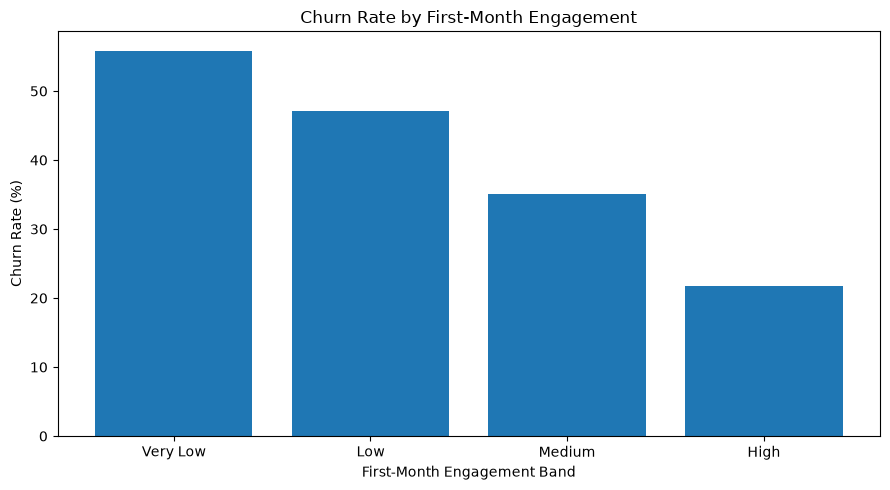

In [3]:
# STEP 14: Analyze first-month engagement vs churn

# ---------------------------------------------------
# 1. Churn by first-month engagement band
# ---------------------------------------------------

first_month_churn = (
    customers.groupby(
        "first_month_engagement_band",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum"),
        avg_first_month_workouts=("first_month_workouts", "mean"),
        avg_first_month_minutes=("first_month_minutes", "mean")
    )
    .reset_index()
)

# ---------------------------------------------------
# 2. Calculate churn rate
# ---------------------------------------------------

first_month_churn["churn_rate_pct"] = (
    first_month_churn["churned_customers"]
    / first_month_churn["customers"]
    * 100
).round(2)

# ---------------------------------------------------
# 3. Sort engagement bands
# ---------------------------------------------------

engagement_order = [
    "Very Low",
    "Low",
    "Medium",
    "High"
]

first_month_churn["first_month_engagement_band"] = pd.Categorical(
    first_month_churn["first_month_engagement_band"],
    categories=engagement_order,
    ordered=True
)

first_month_churn = first_month_churn.sort_values(
    "first_month_engagement_band"
)

# ---------------------------------------------------
# 4. Display results
# ---------------------------------------------------

print("CHURN BY FIRST-MONTH ENGAGEMENT")

display(first_month_churn)

# ---------------------------------------------------
# 5. Compare churned vs retained customers
# ---------------------------------------------------

first_month_compare = (
    customers.groupby("churn_flag")
    .agg(
        customers=("customer_id", "nunique"),
        avg_first_month_workouts=("first_month_workouts", "mean"),
        avg_first_month_minutes=("first_month_minutes", "mean"),
        avg_first_month_classes=("first_month_classes", "mean"),
        avg_first_month_support_tickets=(
            "first_month_support_tickets",
            "mean"
        )
    )
    .reset_index()
)

print("\nFIRST-MONTH BEHAVIOR: RETAINED VS CHURNED")

display(first_month_compare)

# ---------------------------------------------------
# 6. Visualization
# ---------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    first_month_churn[
        "first_month_engagement_band"
    ].astype(str),
    first_month_churn["churn_rate_pct"]
)

plt.title("Churn Rate by First-Month Engagement")
plt.xlabel("First-Month Engagement Band")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

MONTHLY CHURN BY PREVIOUS-MONTH ENGAGEMENT


,prev_month_engagement_band,active_customer_months,churn_events,monthly_churn_rate_pct
0,High,4968,115,2.31
1,Low,6810,498,7.31
2,Medium,8470,361,4.26
3,Very Low,6077,643,10.58



MONTHLY CHURN BY SUPPORT CONTACT


,support_contact_flag,active_customer_months,churn_events,monthly_churn_rate_pct
0,0,26967,1353,5.02
1,1,3558,415,11.66



BEHAVIOR BEFORE CHURN VS NON-CHURN MONTHS


,churn_month_flag,avg_prev_month_workouts,avg_prev_month_minutes,avg_prev_month_classes,avg_support_tickets,avg_prev_support_tickets
0,0,4.699490,141.065343,0.761130,0.126194,0.116440
1,1,2.888064,86.894249,0.463203,0.254793,0.138528


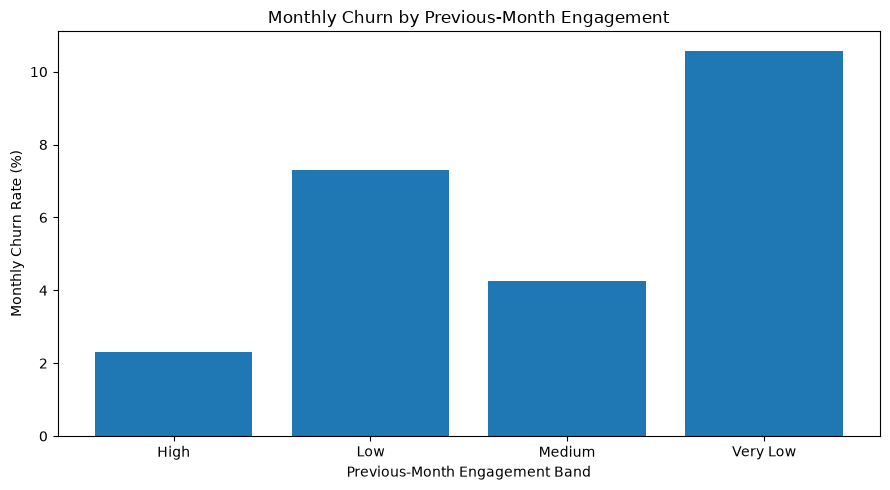

In [4]:
# STEP 15: Analyze previous-month engagement and support contact vs churn

# ---------------------------------------------------
# 1. Load monthly usage feature dataset
# ---------------------------------------------------

monthly_usage = pd.read_csv(
    data_path / "monthly_usage_features.csv"
)

# Convert month columns back to datetime
monthly_usage["month"] = pd.to_datetime(
    monthly_usage["month"]
)

monthly_usage["churn_month"] = pd.to_datetime(
    monthly_usage["churn_month"]
)


# ---------------------------------------------------
# 2. Analyze previous-month engagement band vs churn
# ---------------------------------------------------

prev_engagement_churn = (
    monthly_usage[
        monthly_usage["prev_month_workouts"].notna()
    ]
    .groupby(
        "prev_month_engagement_band",
        observed=False
    )
    .agg(
        active_customer_months=("customer_id", "count"),
        churn_events=("churn_month_flag", "sum")
    )
    .reset_index()
)

prev_engagement_churn["monthly_churn_rate_pct"] = (
    prev_engagement_churn["churn_events"]
    / prev_engagement_churn["active_customer_months"]
    * 100
).round(2)

print("MONTHLY CHURN BY PREVIOUS-MONTH ENGAGEMENT")
display(prev_engagement_churn)


# ---------------------------------------------------
# 3. Analyze support contact vs churn
# ---------------------------------------------------

support_churn = (
    monthly_usage
    .groupby("support_contact_flag")
    .agg(
        active_customer_months=("customer_id", "count"),
        churn_events=("churn_month_flag", "sum")
    )
    .reset_index()
)

support_churn["monthly_churn_rate_pct"] = (
    support_churn["churn_events"]
    / support_churn["active_customer_months"]
    * 100
).round(2)

print("\nMONTHLY CHURN BY SUPPORT CONTACT")
display(support_churn)


# ---------------------------------------------------
# 4. Compare average usage in churn vs non-churn months
# ---------------------------------------------------

usage_compare = (
    monthly_usage[
        monthly_usage["prev_month_workouts"].notna()
    ]
    .groupby("churn_month_flag")
    .agg(
        avg_prev_month_workouts=("prev_month_workouts", "mean"),
        avg_prev_month_minutes=("prev_month_minutes", "mean"),
        avg_prev_month_classes=("prev_month_classes", "mean"),
        avg_support_tickets=("support_tickets", "mean"),
        avg_prev_support_tickets=(
            "prev_month_support_tickets",
            "mean"
        )
    )
    .reset_index()
)

print("\nBEHAVIOR BEFORE CHURN VS NON-CHURN MONTHS")
display(usage_compare)


# ---------------------------------------------------
# 5. Plot previous-month engagement vs churn
# ---------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    prev_engagement_churn[
        "prev_month_engagement_band"
    ].astype(str),
    prev_engagement_churn["monthly_churn_rate_pct"]
)

plt.title("Monthly Churn by Previous-Month Engagement")
plt.xlabel("Previous-Month Engagement Band")
plt.ylabel("Monthly Churn Rate (%)")

plt.tight_layout()
plt.show()

CANCEL REASON DISTRIBUTION


,cancel_reason,customers,cancel_reason_pct
2,not_using_enough,570,32.24
1,not_provided,382,21.61
5,too_expensive,322,18.21
0,found_alternative,175,9.90
3,other,162,9.16
4,technical_issues,157,8.88



FIRST-MONTH BEHAVIOR BY CANCEL REASON


,cancel_reason,customers,avg_first_month_workouts,avg_first_month_minutes,avg_first_month_classes,avg_first_month_support_tickets
2,not_using_enough,570,2.387719,72.184211,0.445614,0.089474
1,not_provided,382,2.897906,86.123037,0.476440,0.104712
5,too_expensive,322,3.742236,109.338509,0.599379,0.077640
0,found_alternative,175,3.440000,106.428571,0.451429,0.057143
3,other,162,3.506173,105.154321,0.629630,0.104938
4,technical_issues,157,3.312102,97.904459,0.535032,0.203822



PRE-CHURN BEHAVIOR BY CANCEL REASON


,cancel_reason,customers,avg_prev_month_workouts,avg_prev_month_minutes,avg_prev_month_classes,avg_churn_month_support_tickets
2,not_using_enough,570,2.191406,65.851562,0.408203,0.215789
1,not_provided,382,2.697740,81.638418,0.378531,0.204188
5,too_expensive,322,3.538983,105.837288,0.569492,0.180124
0,found_alternative,175,3.535484,107.167742,0.580645,0.142857
3,other,162,3.698630,109.308219,0.541096,0.222222
4,technical_issues,157,2.974194,90.967742,0.445161,0.783439


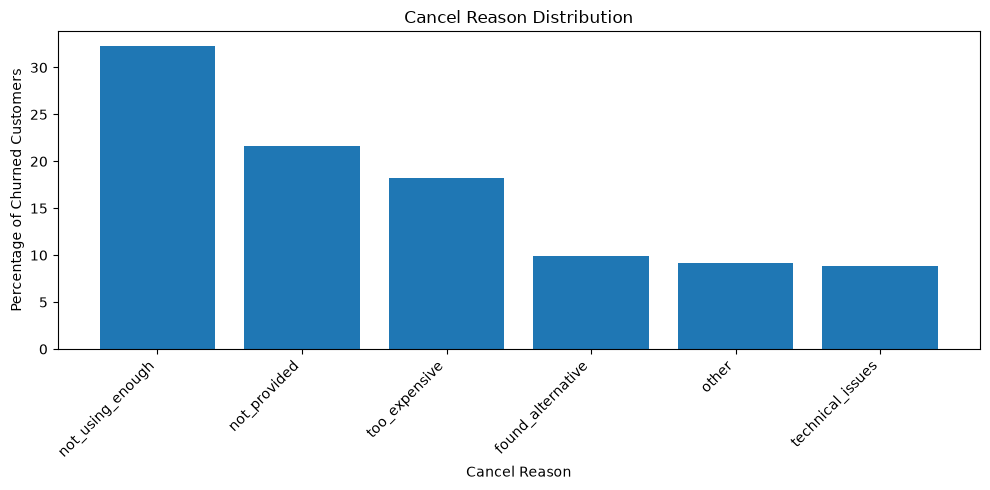

In [5]:
# STEP 16: Compare cancel reasons with actual behavior

# ---------------------------------------------------
# 1. Keep only churned customers
# ---------------------------------------------------

churned_customers = customers[
    customers["churn_flag"] == 1
].copy()


# ---------------------------------------------------
# 2. Cancel reason distribution
# ---------------------------------------------------

cancel_reason_summary = (
    churned_customers
    .groupby("cancel_reason")
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

cancel_reason_summary["cancel_reason_pct"] = (
    cancel_reason_summary["customers"]
    / cancel_reason_summary["customers"].sum()
    * 100
).round(2)

cancel_reason_summary = cancel_reason_summary.sort_values(
    "customers",
    ascending=False
)

print("CANCEL REASON DISTRIBUTION")

display(cancel_reason_summary)


# ---------------------------------------------------
# 3. Compare first-month behavior by cancel reason
# ---------------------------------------------------

cancel_reason_behavior = (
    churned_customers
    .groupby("cancel_reason")
    .agg(
        customers=("customer_id", "nunique"),
        avg_first_month_workouts=("first_month_workouts", "mean"),
        avg_first_month_minutes=("first_month_minutes", "mean"),
        avg_first_month_classes=("first_month_classes", "mean"),
        avg_first_month_support_tickets=(
            "first_month_support_tickets",
            "mean"
        )
    )
    .reset_index()
)

print("\nFIRST-MONTH BEHAVIOR BY CANCEL REASON")

display(
    cancel_reason_behavior.sort_values(
        "customers",
        ascending=False
    )
)


# ---------------------------------------------------
# 4. Get churn-month usage behavior
# ---------------------------------------------------

churn_month_usage = monthly_usage[
    monthly_usage["churn_month_flag"] == 1
].copy()


# ---------------------------------------------------
# 5. Add cancel reason to churn-month usage
# ---------------------------------------------------

churn_month_usage = churn_month_usage.merge(
    customers[
        [
            "customer_id",
            "cancel_reason"
        ]
    ],
    on="customer_id",
    how="left"
)


# ---------------------------------------------------
# 6. Compare behavior immediately before cancellation
# ---------------------------------------------------

cancel_reason_pre_churn = (
    churn_month_usage
    .groupby("cancel_reason")
    .agg(
        customers=("customer_id", "nunique"),
        avg_prev_month_workouts=("prev_month_workouts", "mean"),
        avg_prev_month_minutes=("prev_month_minutes", "mean"),
        avg_prev_month_classes=("prev_month_classes", "mean"),
        avg_churn_month_support_tickets=("support_tickets", "mean")
    )
    .reset_index()
)

print("\nPRE-CHURN BEHAVIOR BY CANCEL REASON")

display(
    cancel_reason_pre_churn.sort_values(
        "customers",
        ascending=False
    )
)


# ---------------------------------------------------
# 7. Technical issues + support contact check
# ---------------------------------------------------

technical_issue_customers = churn_month_usage[
    churn_month_usage["cancel_reason"] == "technical issues"
]

if len(technical_issue_customers) > 0:

    technical_support_rate = (
        technical_issue_customers["support_contact_flag"].mean()
        * 100
    )

    print(
        "\nTechnical-issue churners with support contact:",
        round(technical_support_rate, 2),
        "%"
    )


# ---------------------------------------------------
# 8. Visualization
# ---------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    cancel_reason_summary["cancel_reason"],
    cancel_reason_summary["cancel_reason_pct"]
)

plt.title("Cancel Reason Distribution")
plt.xlabel("Cancel Reason")
plt.ylabel("Percentage of Churned Customers")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [6]:
# STEP 17: Identify top churn factors and control for tenure

# ---------------------------------------------------
# 1. Create tenure-at-month for monthly usage data
# ---------------------------------------------------

monthly_usage["signup_month"] = pd.to_datetime(
    monthly_usage["signup_month"]
)

monthly_usage["tenure_at_month"] = (
    (monthly_usage["month"].dt.year - monthly_usage["signup_month"].dt.year) * 12
    +
    (monthly_usage["month"].dt.month - monthly_usage["signup_month"].dt.month)
)


# ---------------------------------------------------
# 2. Create monthly tenure bands
# ---------------------------------------------------

monthly_usage["monthly_tenure_band"] = pd.cut(
    monthly_usage["tenure_at_month"],
    bins=[-1, 1, 3, 6, 12, 18, 100],
    labels=[
        "0-1 months",
        "2-3 months",
        "4-6 months",
        "7-12 months",
        "13-18 months",
        "18+ months"
    ]
)


# ---------------------------------------------------
# 3. Add plan type to monthly usage
# ---------------------------------------------------

# Avoid duplicate column if cell is run more than once
if "plan_type" not in monthly_usage.columns:

    monthly_usage = monthly_usage.merge(
        customers[
            [
                "customer_id",
                "plan_type"
            ]
        ],
        on="customer_id",
        how="left"
    )


# ===================================================
# FACTOR 1:
# PREVIOUS-MONTH ENGAGEMENT
# ===================================================

engagement_tenure = (
    monthly_usage[
        monthly_usage["prev_month_engagement_band"].notna()
    ]
    .groupby(
        [
            "monthly_tenure_band",
            "prev_month_engagement_band"
        ],
        observed=False
    )
    .agg(
        customer_months=("customer_id", "count"),
        churn_events=("churn_month_flag", "sum")
    )
    .reset_index()
)

engagement_tenure["churn_rate_pct"] = (
    engagement_tenure["churn_events"]
    / engagement_tenure["customer_months"]
    * 100
).round(2)

print("FACTOR 1 - ENGAGEMENT CONTROLLED FOR TENURE")

display(engagement_tenure)


# ===================================================
# FACTOR 2:
# SUPPORT CONTACT
# ===================================================

support_tenure = (
    monthly_usage
    .groupby(
        [
            "monthly_tenure_band",
            "support_contact_flag"
        ],
        observed=False
    )
    .agg(
        customer_months=("customer_id", "count"),
        churn_events=("churn_month_flag", "sum")
    )
    .reset_index()
)

support_tenure["churn_rate_pct"] = (
    support_tenure["churn_events"]
    / support_tenure["customer_months"]
    * 100
).round(2)

print("\nFACTOR 2 - SUPPORT CONTACT CONTROLLED FOR TENURE")

display(support_tenure)


# ===================================================
# FACTOR 3:
# PLAN TYPE
# ===================================================

plan_tenure = (
    monthly_usage
    .groupby(
        [
            "monthly_tenure_band",
            "plan_type"
        ],
        observed=False
    )
    .agg(
        customer_months=("customer_id", "count"),
        churn_events=("churn_month_flag", "sum")
    )
    .reset_index()
)

plan_tenure["churn_rate_pct"] = (
    plan_tenure["churn_events"]
    / plan_tenure["customer_months"]
    * 100
).round(2)

print("\nFACTOR 3 - PLAN TYPE CONTROLLED FOR TENURE")

display(plan_tenure)

FACTOR 1 - ENGAGEMENT CONTROLLED FOR TENURE


,monthly_tenure_band,prev_month_engagement_band,customer_months,churn_events,churn_rate_pct
0,0-1 months,High,574,7,1.22
1,0-1 months,Low,1194,78,6.53
2,0-1 months,Medium,1243,49,3.94
3,0-1 months,Very Low,899,85,9.45
4,2-3 months,High,1310,32,2.44
5,2-3 months,Low,1929,179,9.28
6,2-3 months,Medium,2271,122,5.37
7,2-3 months,Very Low,1337,154,11.52
8,4-6 months,High,1430,23,1.61
9,4-6 months,Low,1873,113,6.03



FACTOR 2 - SUPPORT CONTACT CONTROLLED FOR TENURE


,monthly_tenure_band,support_contact_flag,customer_months,churn_events,churn_rate_pct
0,0-1 months,0,7374,301,4.08
1,0-1 months,1,736,69,9.38
2,2-3 months,0,6152,390,6.34
3,2-3 months,1,695,97,13.96
4,4-6 months,0,6344,234,3.69
5,4-6 months,1,848,74,8.73
6,7-12 months,0,6213,405,6.52
7,7-12 months,1,1081,158,14.62
8,13-18 months,0,884,23,2.60
9,13-18 months,1,198,17,8.59



FACTOR 3 - PLAN TYPE CONTROLLED FOR TENURE


,monthly_tenure_band,plan_type,customer_months,churn_events,churn_rate_pct
0,0-1 months,annual,3063,21,0.69
1,0-1 months,monthly,5047,349,6.91
2,2-3 months,annual,2897,20,0.69
3,2-3 months,monthly,3950,467,11.82
4,4-6 months,annual,3408,35,1.03
5,4-6 months,monthly,3784,273,7.21
6,7-12 months,annual,3838,328,8.55
7,7-12 months,monthly,3456,235,6.80
8,13-18 months,annual,450,2,0.44
9,13-18 months,monthly,632,38,6.01
